# GPU programming lab session

This TP session on GPU programming has main aim to give an initial taste of how CUDA programming looks like.
We will generate and manipulate some simple images.
And we will compare the performances of our GPU programs with the *traditional* sequential equivalent.

The first part of the TP will be closely guided; in the second part, however, only some main directions will be given. Do not hesitate to ask questions to the teacher during the TP!

This lab provides a fantastic opportunity to dive into parallel computing, a critical skill for tackling real-world challenges in fields like AI, scientific simulation, and high-performance data processing.

## Let's get started

We begin by creating an simple image. The simple visualization of the resulting images will allow us to verify whether our CUDA programs are working properly or not.

Please run the Python script below by clicking on the PLAY button. You only need a runtime with a single CPU for running this script.

**Careful**: if you delete or change your runtime, the image will have to be *automatically* regenerated.


In [ ]:
import numpy as np
from PIL import Image
import colorsys

if __name__=='__main__':

    # defining image dimensions
    width = 1024
    height = 256

    # creating an empty array for the image
    img_array = np.zeros((height, width, 3), dtype=np.uint8)

    # generating rainbow colors
    for x in range(width):
        # map x to a hue value (0 to 1) for the rainbow spectrum
        # 0.0 for red, 0.33 for green, 0.66 for blue
        hue = float(x) / width

        # convert HSV to RGB (keeping saturation and value high for vibrant colors)
        rgb_float = colorsys.hsv_to_rgb(hue * 0.7, 1.0, 1.0) # multiplying hue by 0.7 to get more violet instead of magenta
        rgb_int = tuple(int(val * 255) for val in rgb_float)

        # assign the color to the entire vertical bar
        img_array[:, x, :] = rgb_int

    # separating into channels
    red = img_array[:, :, 0]
    green = img_array[:, :, 1]
    blue = img_array[:, :, 2]

    # saving all channels to a single text file
    output_filename = "rgb_channels.txt"
    with open(output_filename, 'w') as f:
        f.write(f"{height} {width}\n") # writing image dimensions
        f.write(f"{' '.join(map(str, red.flatten()))}\n") # writing flattened red channel data
        f.write(f"{' '.join(map(str, green.flatten()))}\n") # writing flattened green channel data
        f.write(f"{' '.join(map(str, blue.flatten()))}\n") # writing flattened blue channel data
    print(f"Generated rainbow image and saved RGB channels to {output_filename}")

    # saving as a JPG to visualize the generated image
    rainbow_image_pil = Image.fromarray(img_array)
    rainbow_image_pil.save("rainbow_generated.jpg")
    print("Saved rainbow_generated.jpg for visualization.")

Generated rainbow image and saved RGB channels to rgb_channels.txt
Saved rainbow_generated.jpg for visualization.


You can visualize the obtained image by running the following script.

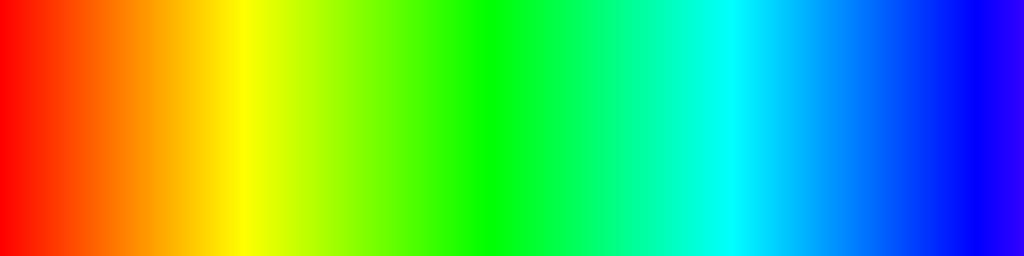

In [ ]:
from IPython.display import Image, display

# Display the inverted image
display(Image(filename='rainbow_generated.jpg'))

Notice that the Python script has also stored the file in text format, where:

* the first line of the text file contains the size of the image;
* the second line contains the red levels for all pixels;
* the third line contains the green levels for all pixels;
* the fourth and last line contains the blue levels for all pixels.

The image pixels are stored row by row. *This is the file that your CUDA code will load*.

You can see all files in the current directory by running:
```
!ls -lah
```

And you can visualize the content of ```rgb_channels.txt``` with
```
!cat rgb_channels.txt
```

**But careful**: this text file is quite big! If you visualize it, your browser may become slower.

## The CUDA code

It is now time to write the CUDA code. We initially focus on a very simple image manipulation: we want to invert all colors of our original image.

A sketch of the code is provided below. Your first task will consist in filling the empty parts (look for the comment **TO BE COMPLETED**).

Notice that the sequential version is also provided, in full.

In [ ]:
%%writefile inv_image.cu
#include <stdio.h>
#include <stdlib.h>

// sequential function
void inv_image_cpu(int *red,int *green,int *blue,int height,int width)
{
   for (int i = 0; i < height*width; i++)  red[i] = 255 - red[i];
   for (int i = 0; i < height*width; i++)  green[i] = 255 - green[i];
   for (int i = 0; i < height*width; i++)  blue[i] = 255 - blue[i];
};

// kernel (we suppose that each thread takes care of only one pixel)
__global__ void inv_image_gpu(int *red,int *green,int *blue,int height,int width)
{
   // TO BE COMPLETED!
   int i = threadIdx.x + blockIdx.x*blockDim.x;
   if(i<height*width){
     red[i] = 255 - red[i];
     green[i] = 255 - green[i];
     blue[i] = 255 - blue[i];
   }
};

// computing CPU clock time
float compute_time(time_t start,time_t end)
{
   return ((float)((int)end - (int)start))/CLOCKS_PER_SEC;
};

// main
int main()
{
   // GPU info
   size_t warp_size = 32;
   size_t warps_per_block = 4;
   size_t nthreads_per_block = warp_size*warps_per_block;
   size_t nblocks;

   // Image data
   int height,width;
   int *red,*green,*blue;
   int *red_gpu,*green_gpu,*blue_gpu;

   // For monitoring execution time
   time_t startclock,endclock;
   float cpu_time,gpu_time;

   // welcome message
   printf("Image color inverter for CPU and GPU\n");

   // loading the text files in the RAM
   FILE *fp;
   printf("loading the image (text file rgb_channels.txt) ... \n");
   fp = fopen("rgb_channels.txt","r");
   fscanf(fp,"%d %d",&height,&width);
   red = (int*)malloc(height*width*sizeof(int));
   for (int i = 0; i < height*width; i++)  fscanf(fp,"%d",&red[i]);
   green = (int*)malloc(height*width*sizeof(int));
   for (int i = 0; i < height*width; i++)  fscanf(fp,"%d",&green[i]);
   blue = (int*)malloc(height*width*sizeof(int));
   for (int i = 0; i < height*width; i++)  fscanf(fp,"%d",&blue[i]);

   // we need a number of blocks sufficient to cover the whole image
   nblocks = (height*width)/nthreads_per_block + 1;

   // memory allocation on GPU
   printf("allocating memory on GPU global memory ...\n");
   size_t total_threads = nblocks*nthreads_per_block;
   // TO BE COMPLETED ...
   cudaMalloc((void**)&red_gpu,total_threads*sizeof(int));
   cudaMalloc((void**)&green_gpu,total_threads*sizeof(int));
   cudaMalloc((void**)&blue_gpu,total_threads*sizeof(int));

   // transferring the three color channels on GPU global memory
   printf("transferring the three color channels on GPU ...\n");
   // TO BE COMPLETED ...
   cudaMemcpy(red_gpu,red,total_threads*sizeof(int),cudaMemcpyHostToDevice);
   cudaMemcpy(green_gpu,green,total_threads*sizeof(int),cudaMemcpyHostToDevice);
   cudaMemcpy(blue_gpu,blue,total_threads*sizeof(int),cudaMemcpyHostToDevice);

   // running the sequential function
   printf("running the sequential function ...\n");
   startclock = clock();
   inv_image_cpu(red,green,blue,height,width);
   endclock = clock();
   cpu_time = compute_time(startclock,endclock);
   printf("CPU time: %f\n",cpu_time);

   // running the kernel
   printf("running the kernel ...\n");
   startclock = clock();
   // TO BE COMPLETED!! <<<<<<<<<<<<<<<<<<<<<
   inv_image_gpu<<<nblocks,nthreads_per_block>>>(red_gpu,green_gpu,blue_gpu,height,width);

   cudaDeviceSynchronize();
   endclock = clock();
   gpu_time = compute_time(startclock,endclock);
   printf("GPU time: %f\n",gpu_time);

   // transferring the three color channels from GPU global memory
   // ... and verifying if the results are correct
   printf("transferring the red channel from GPU and verifying correctness ... ");
   int *tmp = (int*)malloc(total_threads*sizeof(int));
   cudaMemcpy(tmp,red_gpu,total_threads*sizeof(int),cudaMemcpyDeviceToHost);
   for (int i = 0; i < total_threads; i++)  if (tmp[i] != red[i]) { printf("ERROR\n"); return 0; }
   printf("OK\n");
   printf("transferring the green channel from GPU and verifying correctness ... ");
   cudaMemcpy(tmp,green_gpu,total_threads*sizeof(int),cudaMemcpyDeviceToHost);
   for (int i = 0; i < total_threads; i++)  if (tmp[i] != green[i]) { printf("ERROR\n"); return 0; }
   printf("OK\n");
   printf("transferring the blue channel from GPU and verifying correctness ... ");
   cudaMemcpy(tmp,blue_gpu,total_threads*sizeof(int),cudaMemcpyDeviceToHost);
   for (int i = 0; i < total_threads; i++)  if (tmp[i] != blue[i]) { printf("ERROR\n"); return 0; }
   printf("OK\n");

   // write solution on text file (same format as input)
   printf("saving the resulting image (text file inv_rgb_channels.txt) ... ");
   fp = fopen("inv_rgb_channels.txt","w");
   fprintf(fp,"%d %d\n",height,width);
   for (int i = 0; i < height*width; i++)  fprintf(fp,"%d ",red[i]);
   fprintf(fp,"\n");
   for (int i = 0; i < height*width; i++)  fprintf(fp,"%d ",green[i]);
   fprintf(fp,"\n");
   for (int i = 0; i < height*width; i++)  fprintf(fp,"%d ",blue[i]);
   fprintf(fp,"\n");
   fclose(fp);

   // freeing memory
   free(tmp);
   free(red);
   free(green);
   free(blue);
   cudaFree(red_gpu);
   cudaFree(green_gpu);
   cudaFree(blue_gpu);
};

Overwriting inv_image.cu


Before compiling your CUDA code, let's verify whether the compiler is available.

*Notice that it is only at this moment that you need to have a GPU associated to your Colab Notebook* (runtime type: **T4**).

Please run the command below in order to verify the presence of the compiler (**nvcc**).

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Wed_Aug_20_01:58:59_PM_PDT_2025
Cuda compilation tools, release 13.0, V13.0.88
Build cuda_13.0.r13.0/compiler.36424714_0


Then run command below to check the presence of the GPU.

In [ ]:
!nvidia-smi

Mon Oct  5 11:32:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

If everything looks fine, then you can launch the compilation, with the command below.

In [ ]:
!nvcc -arch=sm_75 -o inv_image inv_image.cu

If you get no errors at compile time, you can finally try to run your code on GPU.

In [ ]:
!./inv_image

Image color inverter for CPU and GPU
loading the image (text file rgb_channels.txt) ... 
allocating memory on GPU global memory ...
transferring the three color channels on GPU ...
running the sequential function ...
CPU time: 0.002117
running the kernel ...
GPU time: 0.000141
transferring the red channel from GPU and verifying correctness ... OK
transferring the green channel from GPU and verifying correctness ... OK
transferring the blue channel from GPU and verifying correctness ... OK
saving the resulting image (text file inv_rgb_channels.txt) ... 

Your CUDA code saves the resulting image in text format. In order to convert it into JPG file, you can run the following Python script.

In [ ]:
import numpy as np
from PIL import Image

if __name__=='__main__':

    # output filename for the inverted image
    output_jpg_filename = "inv_rgb_channels.jpg"

    # input text file from CUDA code
    input_txt_filename = "inv_rgb_channels.txt"

    # reading the inverted RGB channels from the text file
    with open(input_txt_filename, 'r') as f:
        dimensions = f.readline().split()
        height = int(dimensions[0])
        width = int(dimensions[1])
        red_flat = np.array(list(map(int, f.readline().split())))
        green_flat = np.array(list(map(int, f.readline().split())))
        blue_flat = np.array(list(map(int, f.readline().split())))

    # reshaping the flattened arrays back to image channels
    red_channel = red_flat[:height*width].reshape(height, width)
    green_channel = green_flat[:height*width].reshape(height, width)
    blue_channel = blue_flat[:height*width].reshape(height, width)

    # stacking the channels to form an RGB image array
    inverted_img_array = np.stack((red_channel,green_channel,blue_channel), axis=-1)

    # converting the NumPy array to a PIL Image object
    inverted_image = Image.fromarray(inverted_img_array.astype(np.uint8))

    # saving the inverted image as a JPG file
    inverted_image.save(output_jpg_filename)
    print(f"Saved inverted image to {output_jpg_filename}")

Saved inverted image to inv_rgb_channels.jpg


Finally you can use the script below (the same used above) to visualize the resulting image.

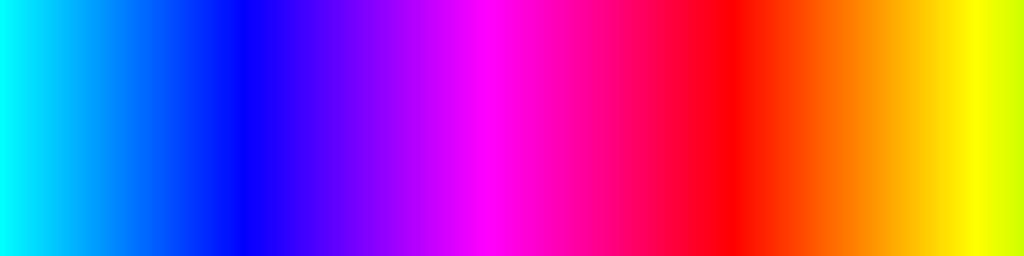

In [ ]:
from IPython.display import Image, display

# Display the inverted image
display(Image(filename='inv_rgb_channels.jpg'))

## If you want to use your own images ...

You can place your images in your Drive and mount the Drive in this Colab Notebook, with the following syntax:

```
from google.colab import drive
drive.mount('/content/drive')
```

The you can use the Python code below to convert images from a wide range of formats, including JPG, PNG, BMP, GIF, and TIFF, into the text format used by our CUDA program.
```
import numpy as np
from PIL import Image

if __name__=='__main__':

    # loading the jpg image
    filename = "/content/drive/My Drive/my_image_file.jpg"
    img = np.array(Image.open(filename))
    height, width = img.shape[:2]
    red = img[:, :, 0]
    green = img[:, :, 1]
    blue = img[:, :, 2]

    # saving all channels to a single text file
    output_filename = "rgb_channels.txt"
    with open(output_filename, 'w') as f:
        f.write(f"{height} {width}\n") # writing image dimensions
        f.write(f"{' '.join(map(str, red.flatten()))}\n") # writing flattened red channel data
        f.write(f"{' '.join(map(str, green.flatten()))}\n") # writing flattened green channel data
        f.write(f"{' '.join(map(str, blue.flatten()))}\n") # writing flattened blue channel data
    print(f"Saved RGB channels to {output_filename}")
```

# More advanced image manipulations

This second part of the TP will not be guided so closely as it has been the case for the first part.

We want to implement now one of the following three filters (proposed in difficulty order, from the easiest to the hardest to implement):

* mean filter
* median filter
* Sobol filter

Your first task will consist in performing a web search on these filters, and to choose one of them to implement on both CPU and GPU.

You can remark that, for all these filters, it is important to have access to the *neighbours* of every pixel. However, the current topology of our GPU grid does not seem to be appropriate for making reference to the neighbours of a given pixel, because their location in a one-dimensional array is not always contiguous. For example, if we need to have access to the upper right neighbour of a given pixel *P* having index *k* in the array, which would the index the neighbour be in the code you completed above?

There are different ways for you to find out how to adapt the topology of your grid to better fit with the two-dimensional nature of our images. You can search the web, you can ask your preferred IA, or to make reference to the sections **Matrix representation** and **Thread grid topology** in [this lecture](https://github.com/mucherino/teaching/blob/main/GPU/matrix-by-matrix.md).

Of course, you can get inspiration from the CUDA code you have completed above; but consider that several changes will be necessary.

That's it. No more information is given for finalizing this TP. Do not hesitate to ask the teacher for any doubts or questions! Embrace the opportunity to innovate and optimize, pushing the boundaries of what's possible with parallel computing!

In [ ]:
%%writefile mean_image.cu
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

// sequential function (Mean filter 3x3)
void mean_image_cpu(int *red, int *green, int *blue,
                    int *red_out, int *green_out, int *blue_out,
                    int height, int width)
{
   for (int row = 0; row < height; row++) {
      for (int col = 0; col < width; col++) {
         int k = row * width + col;

         // Border pixels: keep original value
         if (row == 0 || row == height - 1 || col == 0 || col == width - 1) {
            red_out[k]   = red[k];
            green_out[k] = green[k];
            blue_out[k]  = blue[k];
         } else {
            int sum_r = 0, sum_g = 0, sum_b = 0;
            for (int dy = -1; dy <= 1; dy++) {
               for (int dx = -1; dx <= 1; dx++) {
                  int nk = (row + dy) * width + (col + dx);
                  sum_r += red[nk];
                  sum_g += green[nk];
                  sum_b += blue[nk];
               }
            }
            red_out[k]   = sum_r / 9;
            green_out[k] = sum_g / 9;
            blue_out[k]  = sum_b / 9;
         }
      }
   }
}

// GPU kernel (each thread takes care of one pixel at (row, col))
__global__ void mean_image_gpu(int *red, int *green, int *blue,
                               int *red_out, int *green_out, int *blue_out,
                               int height, int width)
{
   int col = blockIdx.x * blockDim.x + threadIdx.x;
   int row = blockIdx.y * blockDim.y + threadIdx.y;

   if (row < height && col < width) {
      int k = row * width + col;

      if (row == 0 || row == height - 1 || col == 0 || col == width - 1) {
         red_out[k]   = red[k];
         green_out[k] = green[k];
         blue_out[k]  = blue[k];
      } else {
         int sum_r = 0, sum_g = 0, sum_b = 0;
         for (int dy = -1; dy <= 1; dy++) {
            for (int dx = -1; dx <= 1; dx++) {
               int nk = (row + dy) * width + (col + dx);
               sum_r += red[nk];
               sum_g += green[nk];
               sum_b += blue[nk];
            }
         }
         red_out[k]   = sum_r / 9;
         green_out[k] = sum_g / 9;
         blue_out[k]  = sum_b / 9;
      }
   }
}

// computing CPU clock time
float compute_time(time_t start, time_t end)
{
   return ((float)((int)end - (int)start)) / CLOCKS_PER_SEC;
}

// main
int main()
{
   // Image data
   int height, width;
   int *red, *green, *blue;
   int *red_out, *green_out, *blue_out;
   int *red_gpu, *green_gpu, *blue_gpu;
   int *red_gpu_out, *green_gpu_out, *blue_gpu_out;

   // For monitoring execution time
   time_t startclock, endclock;
   float cpu_time, gpu_time;

   // welcome message
   printf("Image 3x3 Mean Filter for CPU and GPU\n");

   // loading the text files in the RAM
   FILE *fp;
   printf("loading the image (text file rgb_channels.txt) ... \n");
   fp = fopen("rgb_channels.txt", "r");
   fscanf(fp, "%d %d", &height, &width);

   size_t num_pixels = height * width;
   size_t img_bytes  = num_pixels * sizeof(int);

   red       = (int*)malloc(img_bytes);
   green     = (int*)malloc(img_bytes);
   blue      = (int*)malloc(img_bytes);
   red_out   = (int*)malloc(img_bytes);
   green_out = (int*)malloc(img_bytes);
   blue_out  = (int*)malloc(img_bytes);

   for (int i = 0; i < num_pixels; i++) fscanf(fp, "%d", &red[i]);
   for (int i = 0; i < num_pixels; i++) fscanf(fp, "%d", &green[i]);
   for (int i = 0; i < num_pixels; i++) fscanf(fp, "%d", &blue[i]);
   fclose(fp);

   // 2D Grid and Block topology (16x16 = 256 threads per block = 8 warps)
   dim3 nthreads_per_block(16, 16);
   dim3 nblocks((width  + nthreads_per_block.x - 1) / nthreads_per_block.x,
                (height + nthreads_per_block.y - 1) / nthreads_per_block.y);

   // memory allocation on GPU (input and output buffers)
   printf("allocating memory on GPU global memory ...\n");
   cudaMalloc((void**)&red_gpu,       img_bytes);
   cudaMalloc((void**)&green_gpu,     img_bytes);
   cudaMalloc((void**)&blue_gpu,      img_bytes);
   cudaMalloc((void**)&red_gpu_out,   img_bytes);
   cudaMalloc((void**)&green_gpu_out, img_bytes);
   cudaMalloc((void**)&blue_gpu_out,  img_bytes);

   // transferring the three input color channels to GPU global memory
   printf("transferring the three color channels on GPU ...\n");
   cudaMemcpy(red_gpu,   red,   img_bytes, cudaMemcpyHostToDevice);
   cudaMemcpy(green_gpu, green, img_bytes, cudaMemcpyHostToDevice);
   cudaMemcpy(blue_gpu,  blue,  img_bytes, cudaMemcpyHostToDevice);

   // running the sequential function
   printf("running the sequential function ...\n");
   startclock = clock();
   mean_image_cpu(red, green, blue, red_out, green_out, blue_out, height, width);
   endclock = clock();
   cpu_time = compute_time(startclock, endclock);
   printf("CPU time: %f\n", cpu_time);

   // running the kernel
   printf("running the kernel ...\n");
   startclock = clock();
   mean_image_gpu<<<nblocks, nthreads_per_block>>>(red_gpu, green_gpu, blue_gpu,
                                                   red_gpu_out, green_gpu_out, blue_gpu_out,
                                                   height, width);
   cudaDeviceSynchronize();
   endclock = clock();
   gpu_time = compute_time(startclock, endclock);
   printf("GPU time: %f\n", gpu_time);

   // transferring the three color channels from GPU global memory and verifying correctness
   printf("transferring the red channel from GPU and verifying correctness ... ");
   int *tmp = (int*)malloc(img_bytes);
   cudaMemcpy(tmp, red_gpu_out, img_bytes, cudaMemcpyDeviceToHost);
   for (int i = 0; i < num_pixels; i++) if (tmp[i] != red_out[i]) { printf("ERROR\n"); return 0; }
   printf("OK\n");

   printf("transferring the green channel from GPU and verifying correctness ... ");
   cudaMemcpy(tmp, green_gpu_out, img_bytes, cudaMemcpyDeviceToHost);
   for (int i = 0; i < num_pixels; i++) if (tmp[i] != green_out[i]) { printf("ERROR\n"); return 0; }
   printf("OK\n");

   printf("transferring the blue channel from GPU and verifying correctness ... ");
   cudaMemcpy(tmp, blue_gpu_out, img_bytes, cudaMemcpyDeviceToHost);
   for (int i = 0; i < num_pixels; i++) if (tmp[i] != blue_out[i]) { printf("ERROR\n"); return 0; }
   printf("OK\n");

   // write solution on text file (same format as input)
   printf("saving the resulting image (text file mean_rgb_channels.txt) ... \n");
   fp = fopen("mean_rgb_channels.txt", "w");
   fprintf(fp, "%d %d\n", height, width);
   for (int i = 0; i < num_pixels; i++) fprintf(fp, "%d ", red_out[i]);
   fprintf(fp, "\n");
   for (int i = 0; i < num_pixels; i++) fprintf(fp, "%d ", green_out[i]);
   fprintf(fp, "\n");
   for (int i = 0; i < num_pixels; i++) fprintf(fp, "%d ", blue_out[i]);
   fprintf(fp, "\n");
   fclose(fp);

   // freeing memory
   free(tmp);
   free(red); free(green); free(blue);
   free(red_out); free(green_out); free(blue_out);
   cudaFree(red_gpu); cudaFree(green_gpu); cudaFree(blue_gpu);
   cudaFree(red_gpu_out); cudaFree(green_gpu_out); cudaFree(blue_gpu_out);

   return 0;
}

Writing mean_image.cu


In [ ]:
!nvcc -arch=sm_75 -o mean_image mean_image.cu
!./mean_image

Image 3x3 Mean Filter for CPU and GPU
loading the image (text file rgb_channels.txt) ... 
allocating memory on GPU global memory ...
transferring the three color channels on GPU ...
running the sequential function ...
CPU time: 0.022306
running the kernel ...
GPU time: 0.000190
transferring the red channel from GPU and verifying correctness ... OK
transferring the green channel from GPU and verifying correctness ... OK
transferring the blue channel from GPU and verifying correctness ... OK
saving the resulting image (text file mean_rgb_channels.txt) ... 


In [ ]:
import numpy as np
from PIL import Image

if __name__=='__main__':

    # output filename for the inverted image
    output_jpg_filename = "mean_rgb_channels.jpg"

    # input text file from CUDA code
    input_txt_filename = "mean_rgb_channels.txt"

    # reading the inverted RGB channels from the text file
    with open(input_txt_filename, 'r') as f:
        dimensions = f.readline().split()
        height = int(dimensions[0])
        width = int(dimensions[1])
        red_flat = np.array(list(map(int, f.readline().split())))
        green_flat = np.array(list(map(int, f.readline().split())))
        blue_flat = np.array(list(map(int, f.readline().split())))

    # reshaping the flattened arrays back to image channels
    red_channel = red_flat[:height*width].reshape(height, width)
    green_channel = green_flat[:height*width].reshape(height, width)
    blue_channel = blue_flat[:height*width].reshape(height, width)

    # stacking the channels to form an RGB image array
    inverted_img_array = np.stack((red_channel,green_channel,blue_channel), axis=-1)

    # converting the NumPy array to a PIL Image object
    inverted_image = Image.fromarray(inverted_img_array.astype(np.uint8))

    # saving the inverted image as a JPG file
    inverted_image.save(output_jpg_filename)
    print(f"Saved inverted image to {output_jpg_filename}")

Saved inverted image to mean_rgb_channels.jpg


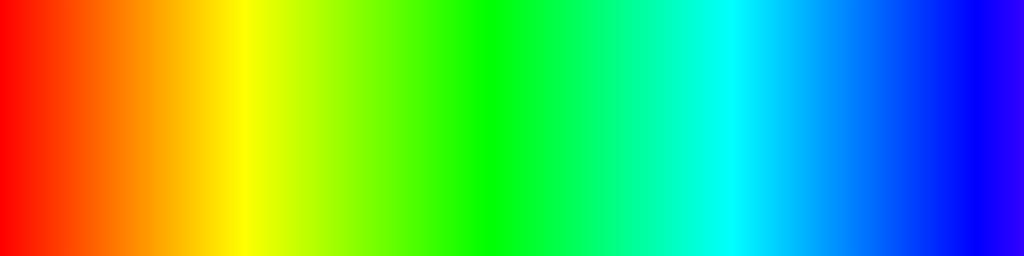

In [ ]:
from IPython.display import Image, display

# Display the inverted image
display(Image(filename='mean_rgb_channels.jpg'))

In [ ]:
%%writefile median_image.cu
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

// Helper sorting function for 9 elements
__host__ __device__ int get_median_9(int *arr) {
    for (int i = 0; i < 5; i++) {
        int min_idx = i;
        for (int j = i + 1; j < 9; j++) {
            if (arr[j] < arr[min_idx]) {
                min_idx = j;
            }
        }
        int temp = arr[i];
        arr[i] = arr[min_idx];
        arr[min_idx] = temp;
    }
    return arr[4]; // The 5th element is the median
}

// sequential function (median filter 3x3)
void median_image_cpu(int *red, int *green, int *blue,
                    int *red_out, int *green_out, int *blue_out,
                    int height, int width)
{
   for (int row = 0; row < height; row++) {
      for (int col = 0; col < width; col++) {
         int k = row * width + col;

         // Border pixels: keep original value
         if (row == 0 || row == height - 1 || col == 0 || col == width - 1) {
            red_out[k]   = red[k];
            green_out[k] = green[k];
            blue_out[k]  = blue[k];
         } else {
            int window_r[9], window_g[9], window_b[9];
            int counter = 0;
            for (int dy = -1; dy <= 1; dy++) {
               for (int dx = -1; dx <= 1; dx++) {
                  int nk = (row + dy) * width + (col + dx);
                  window_r[counter] = red[nk];
                  window_g[counter] = green[nk];
                  window_b[counter] = blue[nk];
                  counter++;
               }
            }
            red_out[k]   = get_median_9(window_r);
            green_out[k] = get_median_9(window_g);
            blue_out[k]  = get_median_9(window_b);
         }
      }
   }
}

// GPU kernel (each thread takes care of one pixel at (row, col))
__global__ void median_image_gpu(int *red, int *green, int *blue,
                               int *red_out, int *green_out, int *blue_out,
                               int height, int width)
{
   int col = blockIdx.x * blockDim.x + threadIdx.x;
   int row = blockIdx.y * blockDim.y + threadIdx.y;

   if (row < height && col < width) {
      int k = row * width + col;

      if (row == 0 || row == height - 1 || col == 0 || col == width - 1) {
         red_out[k]   = red[k];
         green_out[k] = green[k];
         blue_out[k]  = blue[k];
      } else {
         int window_r[9], window_g[9], window_b[9];
         int counter = 0;
         for (int dy = -1; dy <= 1; dy++) {
            for (int dx = -1; dx <= 1; dx++) {
               int nk = (row + dy) * width + (col + dx);
               window_r[counter] = red[nk];
               window_g[counter] = green[nk];
               window_b[counter] = blue[nk];
               counter++;
            }
         }
         red_out[k]   = get_median_9(window_r);
         green_out[k] = get_median_9(window_g);
         blue_out[k]  = get_median_9(window_b);
      }
   }
}

// computing CPU clock time
float compute_time(time_t start, time_t end)
{
   return ((float)((int)end - (int)start)) / CLOCKS_PER_SEC;
}

// main
int main()
{
   // Image data
   int height, width;
   int *red, *green, *blue;
   int *red_out, *green_out, *blue_out;
   int *red_gpu, *green_gpu, *blue_gpu;
   int *red_gpu_out, *green_gpu_out, *blue_gpu_out;

   // For monitoring execution time
   time_t startclock, endclock;
   float cpu_time, gpu_time;

   // welcome message
   printf("Image 3x3 Median Filter for CPU and GPU\n");

   // loading the text files in the RAM
   FILE *fp;
   printf("loading the image (text file rgb_channels.txt) ... \n");
   fp = fopen("rgb_channels.txt", "r");
   fscanf(fp, "%d %d", &height, &width);

   size_t num_pixels = height * width;
   size_t img_bytes  = num_pixels * sizeof(int);

   red       = (int*)malloc(img_bytes);
   green     = (int*)malloc(img_bytes);
   blue      = (int*)malloc(img_bytes);
   red_out   = (int*)malloc(img_bytes);
   green_out = (int*)malloc(img_bytes);
   blue_out  = (int*)malloc(img_bytes);

   for (int i = 0; i < num_pixels; i++) fscanf(fp, "%d", &red[i]);
   for (int i = 0; i < num_pixels; i++) fscanf(fp, "%d", &green[i]);
   for (int i = 0; i < num_pixels; i++) fscanf(fp, "%d", &blue[i]);
   fclose(fp);

   // 2D Grid and Block topology (16x16 = 256 threads per block = 8 warps)
   dim3 nthreads_per_block(16, 16);
   dim3 nblocks((width  + nthreads_per_block.x - 1) / nthreads_per_block.x,
                (height + nthreads_per_block.y - 1) / nthreads_per_block.y);

   // memory allocation on GPU (input and output buffers)
   printf("allocating memory on GPU global memory ...\n");
   cudaMalloc((void**)&red_gpu,       img_bytes);
   cudaMalloc((void**)&green_gpu,     img_bytes);
   cudaMalloc((void**)&blue_gpu,      img_bytes);
   cudaMalloc((void**)&red_gpu_out,   img_bytes);
   cudaMalloc((void**)&green_gpu_out, img_bytes);
   cudaMalloc((void**)&blue_gpu_out,  img_bytes);

   // transferring the three input color channels to GPU global memory
   printf("transferring the three color channels on GPU ...\n");
   cudaMemcpy(red_gpu,   red,   img_bytes, cudaMemcpyHostToDevice);
   cudaMemcpy(green_gpu, green, img_bytes, cudaMemcpyHostToDevice);
   cudaMemcpy(blue_gpu,  blue,  img_bytes, cudaMemcpyHostToDevice);

   // running the sequential function
   printf("running the sequential function ...\n");
   startclock = clock();
   median_image_cpu(red, green, blue, red_out, green_out, blue_out, height, width);
   endclock = clock();
   cpu_time = compute_time(startclock, endclock);
   printf("CPU time: %f\n", cpu_time);

   // running the kernel
   printf("running the kernel ...\n");
   startclock = clock();
   median_image_gpu<<<nblocks, nthreads_per_block>>>(red_gpu, green_gpu, blue_gpu,
                                                   red_gpu_out, green_gpu_out, blue_gpu_out,
                                                   height, width);
   cudaDeviceSynchronize();
   endclock = clock();
   gpu_time = compute_time(startclock, endclock);
   printf("GPU time: %f\n", gpu_time);

   // transferring the three color channels from GPU global memory and verifying correctness
   printf("transferring the red channel from GPU and verifying correctness ... ");
   int *tmp = (int*)malloc(img_bytes);
   cudaMemcpy(tmp, red_gpu_out, img_bytes, cudaMemcpyDeviceToHost);
   for (int i = 0; i < num_pixels; i++) if (tmp[i] != red_out[i]) { printf("ERROR\n"); return 0; }
   printf("OK\n");

   printf("transferring the green channel from GPU and verifying correctness ... ");
   cudaMemcpy(tmp, green_gpu_out, img_bytes, cudaMemcpyDeviceToHost);
   for (int i = 0; i < num_pixels; i++) if (tmp[i] != green_out[i]) { printf("ERROR\n"); return 0; }
   printf("OK\n");

   printf("transferring the blue channel from GPU and verifying correctness ... ");
   cudaMemcpy(tmp, blue_gpu_out, img_bytes, cudaMemcpyDeviceToHost);
   for (int i = 0; i < num_pixels; i++) if (tmp[i] != blue_out[i]) { printf("ERROR\n"); return 0; }
   printf("OK\n");

   // write solution on text file
   printf("saving the resulting image (text file median_rgb_channels.txt) ... \n");
   fp = fopen("median_rgb_channels.txt", "w");
   fprintf(fp, "%d %d\n", height, width);
   for (int i = 0; i < num_pixels; i++) fprintf(fp, "%d ", red_out[i]);
   fprintf(fp, "\n");
   for (int i = 0; i < num_pixels; i++) fprintf(fp, "%d ", green_out[i]);
   fprintf(fp, "\n");
   for (int i = 0; i < num_pixels; i++) fprintf(fp, "%d ", blue_out[i]);
   fprintf(fp, "\n");
   fclose(fp);

   // freeing memory
   free(tmp);
   free(red); free(green); free(blue);
   free(red_out); free(green_out); free(blue_out);
   cudaFree(red_gpu); cudaFree(green_gpu); cudaFree(blue_gpu);
   cudaFree(red_gpu_out); cudaFree(green_gpu_out); cudaFree(blue_gpu_out);

   return 0;
}

Overwriting median_image.cu


In [ ]:
!nvcc -arch=sm_75 -o median_image median_image.cu
!./median_image

Image 3x3 Median Filter for CPU and GPU
loading the image (text file rgb_channels.txt) ... 
allocating memory on GPU global memory ...
transferring the three color channels on GPU ...
running the sequential function ...
CPU time: 0.077133
running the kernel ...
GPU time: 0.000470
transferring the red channel from GPU and verifying correctness ... OK
transferring the green channel from GPU and verifying correctness ... OK
transferring the blue channel from GPU and verifying correctness ... OK
saving the resulting image (text file median_rgb_channels.txt) ... 


In [ ]:
import numpy as np
from PIL import Image

if __name__=='__main__':
    output_jpg_filename = "median_rgb_channels.jpg"
    input_txt_filename = "median_rgb_channels.txt"

    with open(input_txt_filename, 'r') as f:
        dimensions = f.readline().split()
        height = int(dimensions[0])
        width = int(dimensions[1])
        red_flat = np.array(list(map(int, f.readline().split())))
        green_flat = np.array(list(map(int, f.readline().split())))
        blue_flat = np.array(list(map(int, f.readline().split())))

    red_channel = red_flat[:height*width].reshape(height, width)
    green_channel = green_flat[:height*width].reshape(height, width)
    blue_channel = blue_flat[:height*width].reshape(height, width)

    median_img_array = np.stack((red_channel, green_channel, blue_channel), axis=-1)
    median_image = Image.fromarray(median_img_array.astype(np.uint8))
    median_image.save(output_jpg_filename)
    print(f"Saved median filtered image to {output_jpg_filename}")

Saved median filtered image to median_rgb_channels.jpg


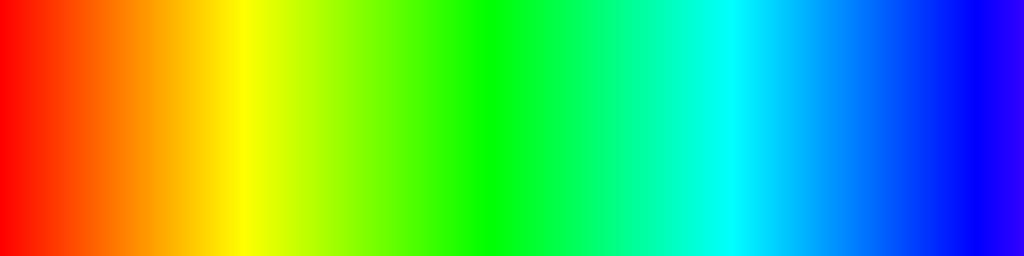

In [ ]:
from IPython.display import Image, display
display(Image(filename='median_rgb_channels.jpg'))